# L1 threshold learning — GMM demo (standalone)

**What this is.** A *data-driven* replacement for the two hand-set dwell cut lines in the
diagnostic agent, learned with a small **unsupervised** model. It lives in
`ml_thresholds.py` and **does not modify `agent_diagnose.py`** — it is additive.

| agent_diagnose.py (current) | this module |
|---|---|
| `QUEUE_CAP = 120 min` (hand-set) | **GMM** learns the work/queue ↔ long-stop cut per zone |
| `PARK_CAP = 360 min` (hand-set) | not a dwell mode → the on-shift/off-shift split uses a **time-of-day** signal (overnight) |

**Method.** Model `log(dwell)` as a Gaussian Mixture, fit by EM (maximum likelihood),
pick K by BIC, take the cut = the density valley (antimode) between the two dominant modes.
Unsupervised → no cause labels needed → keeps the interpretable, no-training frame.

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '.')          # run from analysis/
import pandas as pd
import ml_thresholds as mlt
pd.set_option('display.width', 120)
ZONE = 25559   # BN load (Баруун наран /Зүүн/)

## 1. Load the dwell distribution
One value per completed loading stop: `dwell = next depart_load − this arrive_load`
(same truck), exactly as the agent's perception layer computes it.

In [2]:
d = mlt.load_dwell(ZONE, '2025-11')
print(f"{len(d)} loading stops in Nov")
d['dwell_min'].describe(percentiles=[.1,.2,.5,.8,.9,.95]).round(1)

2395 loading stops in Nov


count    2395.0
mean      180.0
std       561.6
min         0.3
10%        13.5
20%        16.2
50%        27.0
80%        52.0
90%       500.7
95%      1061.9
max      9292.4
Name: dwell_min, dtype: float64

The distribution is heavily right-skewed (median ~27 min, but a long tail to thousands of
minutes). That tail is overnight parking — the second hump.

## 2. Fit the GMM and choose K by BIC
`BIC = −2·logL + p·ln(n)` — lower is better; the penalty `p·ln(n)` stops K from inflating.

In [3]:
res = mlt.fit_dwell_gmm(d['dwell_min'])
print("BIC by K:", {k: round(v,1) for k,v in res['bic_by_k'].items()})
print("best K   :", res['best_k'])
for i, m in enumerate(res['components'], 1):
    print(f"  mode {i}: ~{m['mean_min']:7.1f} min   weight {m['weight']:.2f}")
print("learned cut(s):", [round(x,1) for x in res['cut_points']], "min   (hand-set was 120)")

BIC by K: {1: 8199.8, 2: 5844.7, 3: 5868.3, 4: 5912.0, 5: 5913.4}
best K   : 2
  mode 1: ~   24.5 min   weight 0.87
  mode 2: ~  878.7 min   weight 0.13
learned cut(s): [147.6] min   (hand-set was 120)


**Reading it.** BIC picks **K=2**: a ~24-min *working* mode (87%) and a ~15-hour *parked*
mode (13%). One valley between them ≈ 148 min — remarkably close to the hand-set 120.
BIC does **not** support a third "on-shift idle" hump → the 6 h line is not a density mode.

## 3. Visualise: two modes + learned cut vs hand-set lines

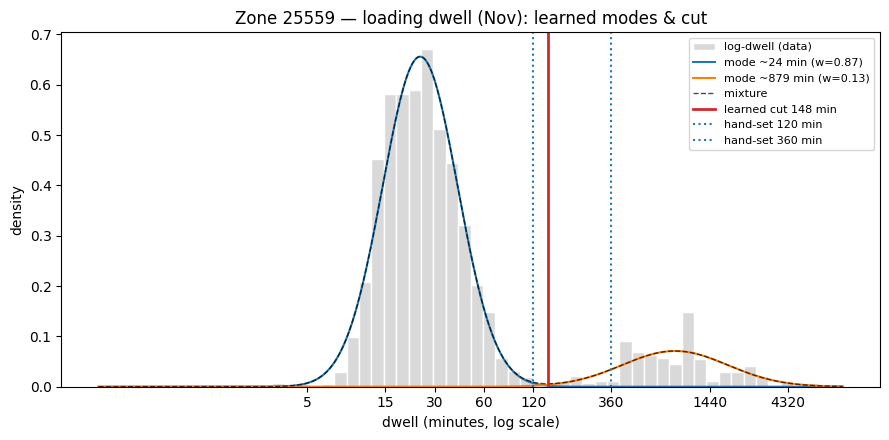

In [4]:
ax = mlt.plot_dwell_gmm(d['dwell_min'], res, handset=(120, 360),
                        title=f'Zone {ZONE} — loading dwell (Nov): learned modes & cut')
import matplotlib.pyplot as plt; plt.tight_layout(); plt.show()

## 4. Per-month stability — why we *freeze* one cut
Fit the K=2 cut separately for each month. If it drifts a lot, a single per-month cut would
mean measuring every month with a *different ruler* — you could not tell a real change in
queueing from a moving threshold.

In [5]:
mlt.per_month_table(ZONE)

,month,n,work_min,park_min,w_work,bic_k,cut_min
0,2025-07,1492,17.4,271.0,0.74,5,59.6
1,2025-08,2395,17.2,569.3,0.81,3,61.0
2,2025-09,2303,21.5,759.2,0.84,4,111.5
3,2025-10,2711,24.5,799.8,0.85,4,140.2
4,2025-11,2395,24.5,878.7,0.87,2,147.6


The cut climbs 60 → 148 min as the operation matures (fleet grows, the long-stop tail
lengthens 271 → 879 min). July is a ramp-up regime (few trucks) and is excluded from the
frozen cut. **Take-away: freeze one cut for cross-month comparability; report the drift as a
finding, don't hide it.**

## 5. The frozen cut + the second (overnight) split
`learn_thresholds` returns both thresholds the agent needs — the GMM cut (frozen on the
steady-state months) and the time-of-day rule for on-shift idle vs off-shift downtime —
as a dict that could be *passed into* a future diagnosis run **without changing the agent**.

In [6]:
lt = mlt.learn_thresholds(ZONE)
print("frozen queue_cut :", lt['queue_cut_min'], "min")
print("method           :", lt['method'])
print("2nd-cut method   :", lt['second_cut_method'])

df, summ = mlt.classify_stops(mlt.load_dwell(ZONE, '2025-11'), lt['queue_cut_min'])
print("\nNov stops split with the learned cut + overnight rule:")
summ

frozen queue_cut : 110.2 min
method           : GMM(K=2) antimode on log(dwell); frozen on steady-state months
2nd-cut method   : time-of-day: stop spans overnight (not a dwell mode)



Nov stops split with the learned cut + overnight rule:


,n,truck_h
state,,
downtime,187,4943.6
on_shift_idle,133,1275.8
working,2075,965.6


`working` = load + short queue; `on_shift_idle` = long but not overnight (recoverable-ish);
`downtime` = long and overnight (a staffing lever, not dispatch). This is the same
on-shift/off-shift story the slides make, but with a learned cut and an overnight signal
instead of two hand-set constants.

## 6. Generalisation — same code, different zone
Run the identical pipeline on Middling (25385). A different flow → a different learned cut,
with no code change.

In [7]:
for zid, nm in [(25559, 'BN'), (25385, 'Middling')]:
    w, p, ww, cut = mlt.fit_two_modes(mlt.load_dwell(zid, '2025-11')['dwell_min'])
    print(f"{nm:9} (zone {zid}): work ~{w:5.1f} min | park ~{p:6.1f} min | learned cut {cut:5.1f} min")

BN        (zone 25559): work ~ 24.5 min | park ~ 878.7 min | learned cut 147.6 min


Middling  (zone 25385): work ~  3.9 min | park ~ 556.0 min | learned cut  89.9 min


## Takeaways & honesty

- **The first cut is data-driven & per-zone.** GMM learns it from the dwell distribution
  (unsupervised → keeps the interpretable frame); it is cycle-relative, replacing the global
  120 min constant. This directly retires the *"provisional, BN-tuned"* caveat for that line.
- **The second cut is not a dwell mode.** BIC finds only two humps, so on-shift-idle vs
  off-shift-downtime is decided by a **time-of-day** signal (overnight), which is
  month-invariant by construction.
- **Freeze for comparability.** Use one cut across months; keep the per-month fit as a
  stability diagnostic.
- **Caveat.** Forcing K=2 assumes a work-vs-park bimodal shape. Where it does not hold
  (e.g. Reject 25384, two close modes), inspect the fit or fall back to BIC-selected K.
- **Unchanged frame.** Still a diagnostic, not proof; learned cuts are still an upper-bound
  device; no payload; a real gain needs a before/after pilot.

**Integration path (later, not done here):** add an optional `thresholds=` argument to
`diagnose(...)` and feed it `learn_thresholds(zone_id)` — the agent stays backward-compatible
and untouched by this notebook.